In [9]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from astropy import units as u
# from astropy.constants import k_B, N_A
from astropy.visualization import quantity_support
quantity_support();
from scipy import signal

**1. Расчёт частот, генерируемых таймером Ардуино при использовании предзагрузки счётчика**

Если 16-разрядный счётчик каждый раз при переполнении вызывает прерывание, и в программе обработки прерываний в счётчик записывается число $N_0<2^{16}$, то при тактовой частоте $F$ и коэффициенте $k$ деления предделителя частота прерываний

\begin{equation}
f=\frac{F}{k} \frac{1}{2^{16}-N_0}
\end{equation}


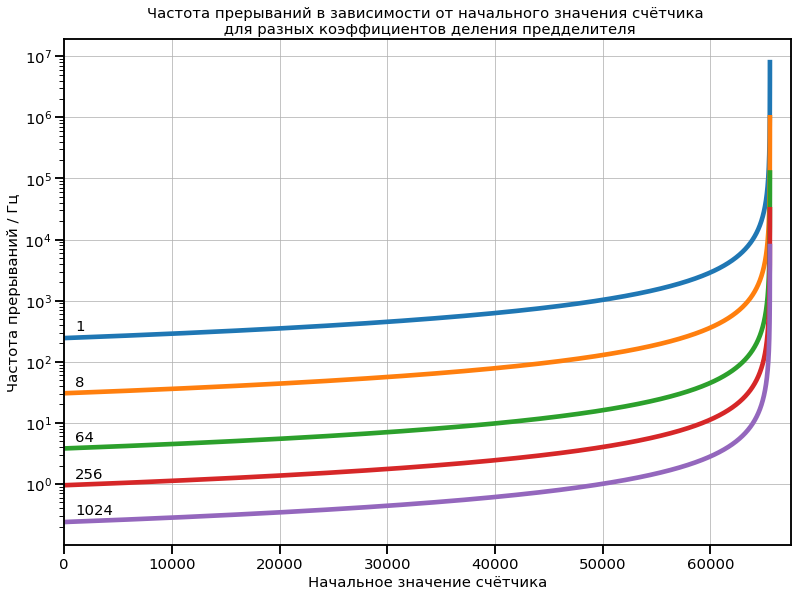

In [11]:
# plt.figure(figsize=(14, 10))
# plt.subplot(1, 2, 1)   # 1 строка, 2 колонки, ячейка 1

fig = plt.figure(figsize=(14, 10), dpi=67)
ax = fig.add_subplot(111)

F = 16e6 * u.Hz
ks = [1, 8, 64, 256, 1024]
N0s = np.arange(0, 65535)
for k in ks:
    fs = F/ k/ (65536 - N0s)
    plt.semilogy(N0s, fs, linewidth=5)
    plt.text(1000, 1.3*fs[0], k, fontsize=16)
plt.xlim(left=0, right=67500)
plt.xlabel('Начальное значение счётчика', fontsize=16)
plt.ylabel('Частота прерываний / Гц', fontsize=16)

plt.tick_params(axis='both', which='major', length=10, width=2, labelsize=16)
plt.tick_params(axis='both', which='minor', length=5, width=1)
plt.grid(True)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.title('Частота прерываний в зависимости от начального значения счётчика \n для разных коэффициентов деления предделителя', fontsize=16);
plt.savefig('260312_graph.jpg', bbox_inches='tight')

**2. Расчёт начального значения $N_0$ для заданной выходной частоты f при заданном коэффициенте k деления**
\begin{equation}
N_0 = 65536 - \frac{8 \ \mathrm{MHz}}{kf}
\end{equation}
Выходная частота $f$ вдвое ниже частоты прерываний, поэтому в формуле 8 МГц, а не 16.
Следует понимать, что график не сплошная линия, а множество отдельных точек, поэтому не для всякой заданной частоты $f$ найдётся значение $N_0$. Формальный расчёт возможен для любой $f$, но результат может не оказаться целым положительным числом, что означает невозможность получить заданную $f$.

In [2]:
# Функция для расчёта начального значения счётчика при заданной частоте f и коэффициенте k деления

def N0(k, f):
    return 65536 - 8000000/k/f

N0(1, 8000000)

65535.0

In [41]:
def N0str(k, f):
    N0 = 65536 - 8000000/k/f
    intN0 = int(N0)
    if N0==intN0 and N0 > 0 : return ' ' + '{:5d}'.format(intN0) + ' '
#     str(intN0) # проверка на целость и положительность
    else: return '       '

N0str(1024, 1)

'       '

In [73]:
# Расчёт начального значения счётчика при разных коэффициентах деления предделителя
# для получения некоторых частот
# Значения получены в предположении, что на обработку прерывания время не тратится. Фактические значения заметно ниже расчетных
# уже при частотах в несколько кГц и выше.


c = 6              #количество столбцов в таблице
p = 7              #ширина столбца
line = '─' * ( p*c + c - 1 + 5)    # горизонтальная линия в таблице
print(line)
S = '            '
for k in ks:
    S = S + '|' + ' ' + '{:5d}'.format(k) + ' '
print(S+ '|')    
print(line)

fs = [1, 2, 2.5, 3, 4, 5, 6, 7, 7.5, 8, 9]
scales = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
for scale in scales:
    for f in fs:
        F = f * scale
        S = ' '
        for k in ks:
            S = S + '|' + N0str(k,F)
        S = ' ' + f"{F:10.2f}" + S + '|' # f"{f:.1f} означает: f-строка (первое f), вывести переменную f (второе f)
                                       # типа float (третье f)
        print(S)

# Частота в герцах в левом столбце. 
# Отсутствие в таблице вычисленного начального значения счётчика для данной частоты и коэф-та деления
# означает невозможность получения этой частоты при этом коэф-те        

────────────────────────────────────────────────────
            |     1 |     8 |    64 |   256 |  1024 |
────────────────────────────────────────────────────
       0.10 |       |       |       |       |       |
       0.20 |       |       |       |       |       |
       0.25 |       |       |       |       | 34286 |
       0.30 |       |       |       |       |       |
       0.40 |       |       |       |       |       |
       0.50 |       |       |       |  3036 | 49911 |
       0.60 |       |       |       |       |       |
       0.70 |       |       |       |       |       |
       0.75 |       |       |       |       |       |
       0.80 |       |       |       |       |       |
       0.90 |       |       |       |       |       |
       1.00 |       |       |       | 34286 |       |
       2.00 |       |       |  3036 | 49911 |       |
       2.50 |       |       | 15536 | 53036 | 62411 |
       3.00 |       |       |       |       |       |
       4.00 |       |       | 

In [50]:
!python --version

Python 3.8.5
